# 1NN vs RandomForest

Сравним ближайшего соседа и случайный лес на распознавании рукописных цифр, изучим accuracy, матрицы ошибок и примеры неверных прогнозов.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

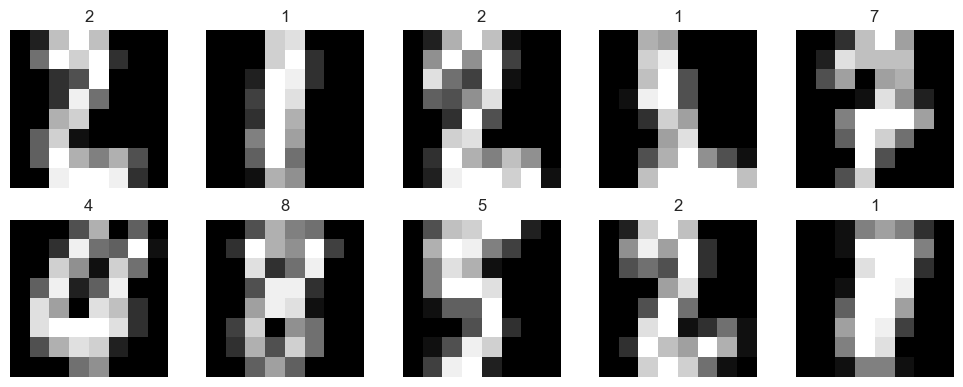

In [2]:
digits = load_digits()
features = digits.data
target = digits.target
train_features, test_features, train_target, test_target, train_images, test_images = train_test_split(
    features, target, digits.images, test_size=0.25, random_state=42, stratify=target
)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for axis, image, label in zip(axes.ravel(), train_images[:10], train_target[:10]):
    axis.imshow(image, cmap="gray")
    axis.set_title(str(label))
    axis.axis("off")
plt.tight_layout()
plt.show()

In [3]:
models = {
    "1NN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=1)),
    ]),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=1, random_state=42),
}
predictions = {}
rows = []
for name, model in models.items():
    model.fit(train_features, train_target)
    prediction = model.predict(test_features)
    predictions[name] = prediction
    rows.append({"model": name, "accuracy": accuracy_score(test_target, prediction)})

pd.DataFrame(rows).set_index("model")

,accuracy
model,
1NN,0.971111
Random Forest,0.968889


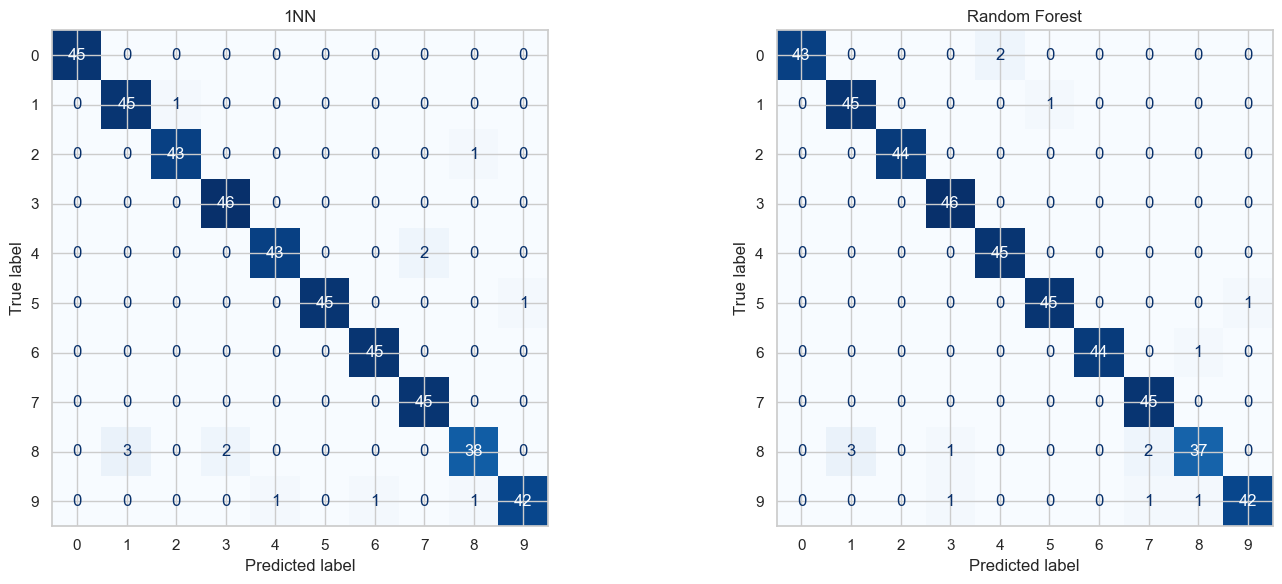

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, (name, prediction) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(test_target, prediction, ax=axis, cmap="Blues", colorbar=False)
    axis.set_title(name)
plt.tight_layout()
plt.show()

## Ошибки Random Forest

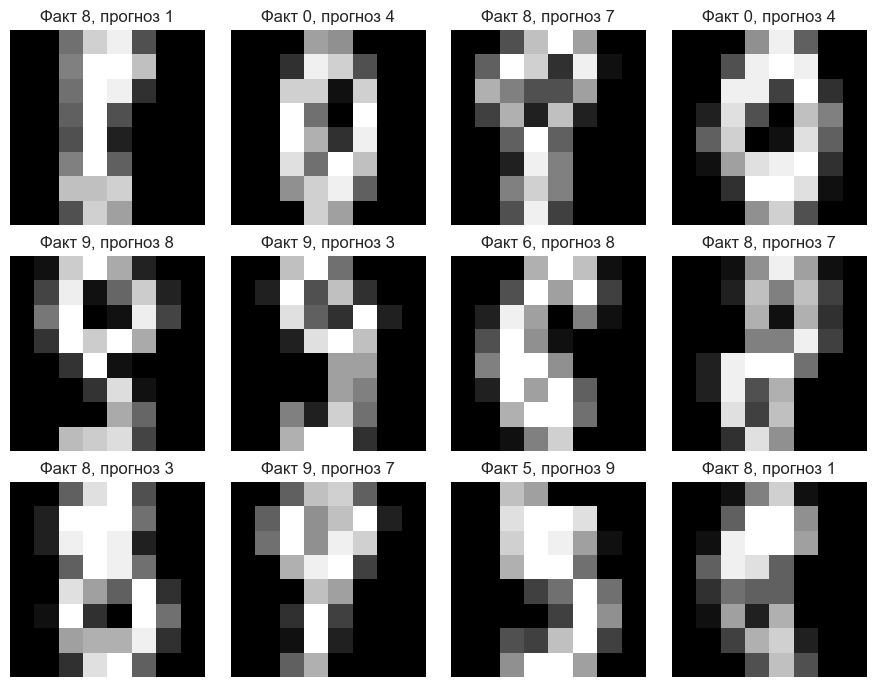

In [5]:
forest_prediction = predictions["Random Forest"]
error_indices = np.flatnonzero(forest_prediction != test_target)[:12]

fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for axis, index in zip(axes.ravel(), error_indices):
    axis.imshow(test_images[index], cmap="gray")
    axis.set_title(f"Факт {test_target[index]}, прогноз {forest_prediction[index]}")
    axis.axis("off")
plt.tight_layout()
plt.show()

## Вывод

1NN хранит обучающую выборку и чувствителен к масштабу признаков. Random Forest строит ансамбль деревьев, лучше сглаживает шум и обычно устойчивее на многомерных данных.

## Расширенное сравнение алгоритмов

In [6]:
import time
import numpy as np
from sklearn.metrics import classification_report
from sklearn.model_selection import learning_curve

### Время обучения и инференса

In [7]:
timing_rows = []
for name, estimator in models.items():
    start = time.perf_counter()
    estimator.fit(train_features, train_target)
    fit_seconds = time.perf_counter() - start
    start = time.perf_counter()
    timed_prediction = estimator.predict(test_features)
    predict_seconds = time.perf_counter() - start
    timing_rows.append({
        "model": name,
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
        "accuracy": accuracy_score(test_target, timed_prediction),
    })

pd.DataFrame(timing_rows).set_index("model")

,fit_seconds,predict_seconds,accuracy
model,,,
1NN,0.000854,0.003154,0.971111
Random Forest,0.359907,0.009866,0.968889


### Подбор числа соседей

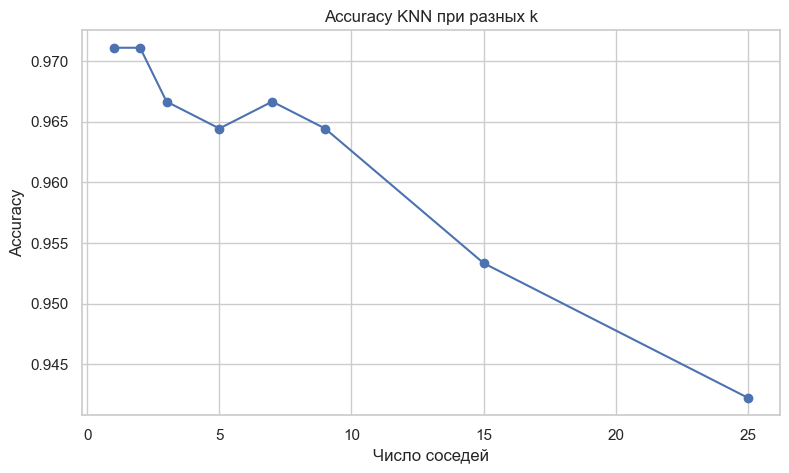

In [8]:
neighbor_rows = []
for neighbors in [1, 2, 3, 5, 7, 9, 15, 25]:
    estimator = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=neighbors, weights="distance")),
    ])
    estimator.fit(train_features, train_target)
    neighbor_rows.append({
        "neighbors": neighbors,
        "accuracy": accuracy_score(test_target, estimator.predict(test_features)),
    })

neighbor_results = pd.DataFrame(neighbor_rows)
plt.figure(figsize=(9, 5))
plt.plot(neighbor_results["neighbors"], neighbor_results["accuracy"], marker="o")
plt.title("Accuracy KNN при разных k")
plt.xlabel("Число соседей")
plt.ylabel("Accuracy")
plt.show()

### Число деревьев Random Forest

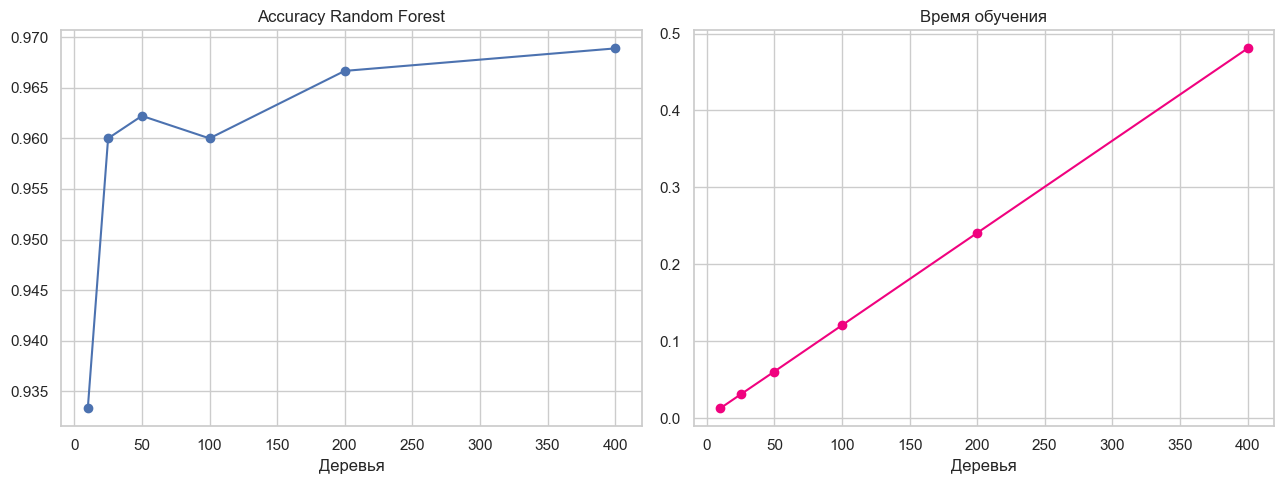

In [9]:
forest_rows = []
for trees in [10, 25, 50, 100, 200, 400]:
    estimator = RandomForestClassifier(n_estimators=trees, n_jobs=1, random_state=42)
    start = time.perf_counter()
    estimator.fit(train_features, train_target)
    forest_rows.append({
        "trees": trees,
        "accuracy": accuracy_score(test_target, estimator.predict(test_features)),
        "fit_seconds": time.perf_counter() - start,
    })

forest_results = pd.DataFrame(forest_rows)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(forest_results["trees"], forest_results["accuracy"], marker="o")
axes[0].set_title("Accuracy Random Forest")
axes[0].set_xlabel("Деревья")
axes[1].plot(forest_results["trees"], forest_results["fit_seconds"], marker="o", color="#f0027f")
axes[1].set_title("Время обучения")
axes[1].set_xlabel("Деревья")
plt.tight_layout()
plt.show()

### Качество по каждому классу

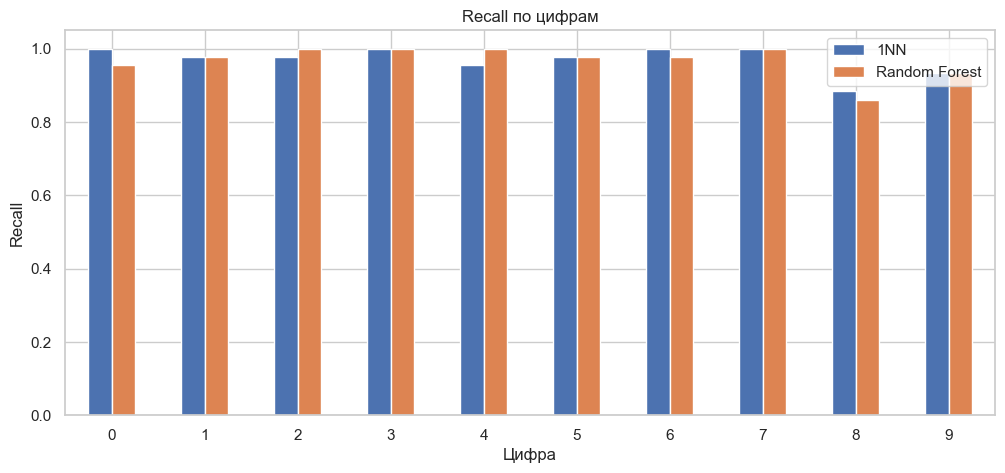

In [10]:
reports = {}
for name, model_prediction in predictions.items():
    report = pd.DataFrame(classification_report(test_target, model_prediction, output_dict=True)).T
    reports[name] = report.loc[[str(digit) for digit in range(10)], "recall"]

recall_by_class = pd.DataFrame(reports)
recall_by_class.plot.bar(figsize=(12, 5))
plt.title("Recall по цифрам")
plt.xlabel("Цифра")
plt.ylabel("Recall")
plt.xticks(rotation=0)
plt.show()

### Карта важности пикселей

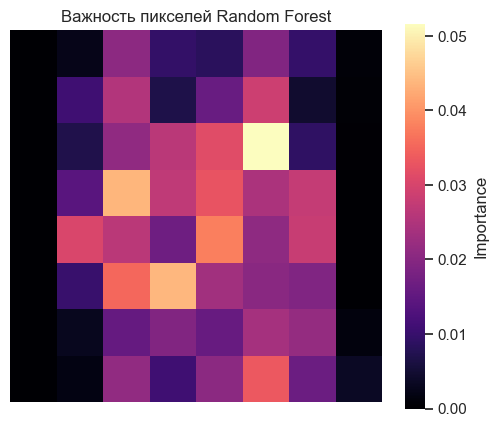

In [11]:
forest_model = models["Random Forest"]
pixel_importance = forest_model.feature_importances_.reshape(8, 8)

plt.figure(figsize=(6, 5))
sns.heatmap(pixel_importance, cmap="magma", square=True, cbar_kws={"label": "Importance"})
plt.title("Важность пикселей Random Forest")
plt.axis("off")
plt.show()

### Learning curves

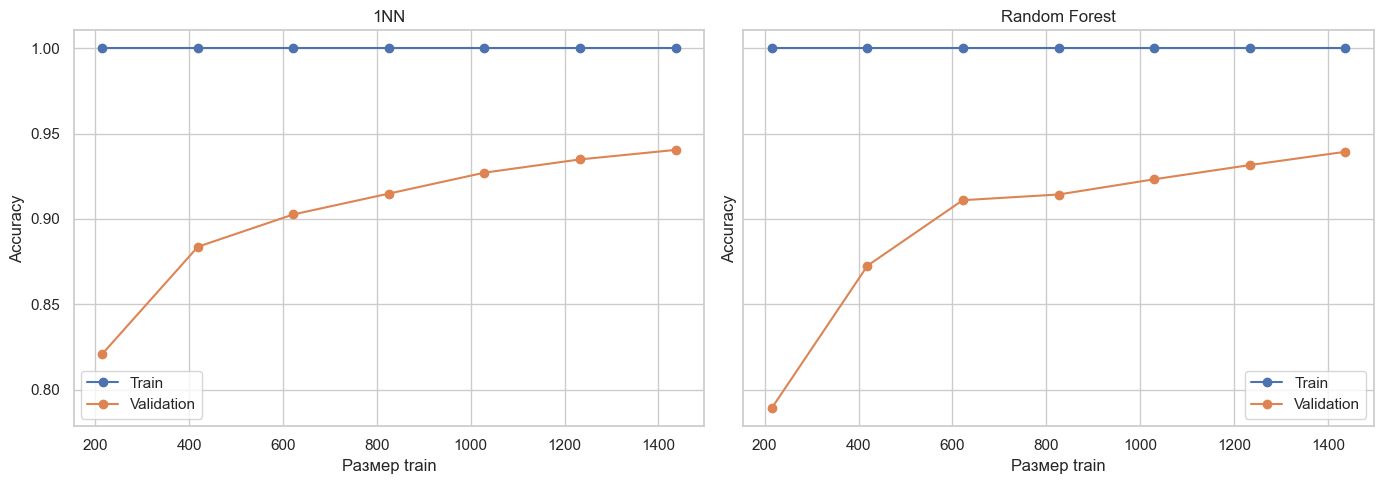

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, (name, estimator) in zip(axes, models.items()):
    sizes, train_scores, validation_scores = learning_curve(
        estimator,
        features,
        target,
        cv=5,
        scoring="accuracy",
        train_sizes=np.linspace(0.15, 1.0, 7),
        n_jobs=1,
    )
    axis.plot(sizes, train_scores.mean(axis=1), marker="o", label="Train")
    axis.plot(sizes, validation_scores.mean(axis=1), marker="o", label="Validation")
    axis.set_title(name)
    axis.set_xlabel("Размер train")
    axis.set_ylabel("Accuracy")
    axis.legend()
plt.tight_layout()
plt.show()

### Итог расширенного анализа

KNN почти не тратит время на обучение, но стоимость инференса растёт с train-выборкой. Random Forest обучается дольше, зато быстро предсказывает и показывает пространственную важность пикселей. Сравнивать модели нужно не только по accuracy, но и по latency и качеству отдельных классов.